<a href="https://colab.research.google.com/github/limaguus/ai-data-insights/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd

df = pd.read_csv("sales.csv")
df.head()

,date,product,category,quantity,price,revenue
0,01/01/2024,Mouse,Eletronicos,2,50,100
1,02/01/2024,Teclado,Eletronicos,1,120,120
2,03/01/2024,Camiseta,Roupas,3,40,120
3,04/01/2024,Tenis,Roupas,1,200,200
4,05/01/2024,Fone,Eletronicos,2,80,160


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      8 non-null      object
 1   product   8 non-null      object
 2   category  8 non-null      object
 3   quantity  8 non-null      int64 
 4   price     8 non-null      int64 
 5   revenue   8 non-null      int64 
dtypes: int64(3), object(3)
memory usage: 516.0+ bytes


In [16]:
df.describe()

,quantity,price,revenue
count,8.000000,8.000000,8.000000
mean,1.625000,216.250000,253.750000
std,0.744024,285.704018,265.703245
min,1.000000,40.000000,100.000000
25%,1.000000,72.500000,120.000000
50%,1.500000,105.000000,170.000000
75%,2.000000,212.500000,212.500000
max,3.000000,900.000000,900.000000


In [17]:
total_revenue = df["revenue"].sum()
average_ticket = df["revenue"].mean()

top_product = df.groupby("product")["revenue"].sum().sort_values(ascending=False)
top_category = df.groupby("category")["revenue"].sum().sort_values(ascending=False)

print("Faturamento total:", total_revenue)
print("Ticket médio:", average_ticket)

print("\nTop produtos por receita:")
print(top_product)

print("\nReceita por categoria:")
print(top_category)

Faturamento total: 2030
Ticket médio: 253.75

Top produtos por receita:
product
Monitor     900
Jaqueta     250
Tenis       200
Calca       180
Fone        160
Camiseta    120
Teclado     120
Mouse       100
Name: revenue, dtype: int64

Receita por categoria:
category
Eletronicos    1280
Roupas          750
Name: revenue, dtype: int64


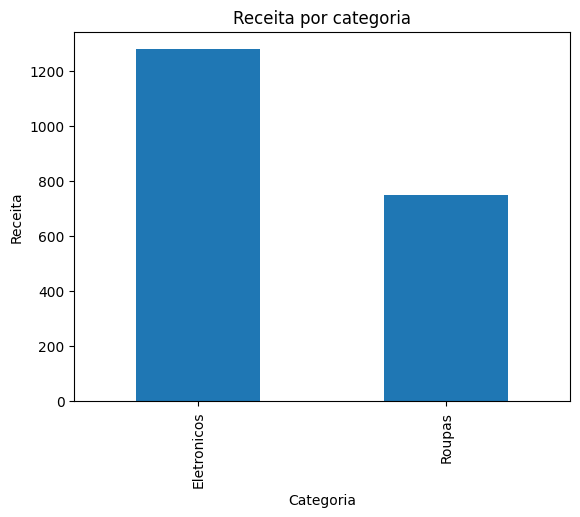

In [18]:
import matplotlib.pyplot as plt

top_category.plot(kind="bar")
plt.title("Receita por categoria")
plt.ylabel("Receita")
plt.xlabel("Categoria")
plt.show()

Insights da análise:

A categoria Eletrônicos gerou a maior receita, indicando maior valor agregado por produto
O produto Monitor foi o principal responsável pelo faturamento total
A categoria Roupas teve bom volume de vendas, mas menor ticket médio
Existe oportunidade de aumentar o preço médio em roupas ou vender mais itens premium
O ticket médio geral indica potencial para estratégias de upsell

In [19]:
!pip install openai

In [27]:
from openai import OpenAI

client = OpenAI(api_key="SUA_API_KEY")

In [28]:
summary = f"""
Faturamento total: {total_revenue}
Ticket médio: {average_ticket}

Top produtos:
{top_product.head(3)}

Top categorias:
{top_category}
"""

In [30]:
response = client.chat.completions.create(
    model="gpt-4.1-mini",
    messages=[
        {
            "role": "user",
            "content": f"""
            Você é um analista de dados.

            Analise os dados abaixo e gere insights claros e objetivos:

            {summary}
            """
        }
    ]
)

print(response.choices[0].message.content)

AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: SUA_API_KEY. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_api_key'}}